# Sistemas Inteligentes – Exercícios 4, 5 e 6

- **Exercício 4**: `tanimoto_similarity`
- **Exercício 5**: PCA aplicado ao iris.
- **Exercício 6**: `stratified_train_test_split`


In [7]:
from pathlib import Path
import numpy as np

from si.io.csv_file import read_csv
from si.statistics.tanimoto_similarity import tanimoto_similarity
from si.decomposition.pca import PCA
from si.model_selection.split import stratified_train_test_split
import matplotlib.pyplot as plt

iris_path = Path(r"C:\Users\filip\OneDrive\Attachments\Ambiente de Trabalho\SIB_gh\si2\datasets\iris\iris.csv")
iris_ds = read_csv(iris_path, sep=",", features=True, label=True)
X, y = iris_ds.X, iris_ds.y


# Exercício 4

**Exercício 4 – Exemplo de tanimoto_similarity**

In [2]:
x = np.array([1, 0, 1, 0], dtype=int)
y_bin = np.array([
    [1, 0, 1, 0],
    [1, 1, 0, 0],
    [0, 0, 0, 0]
], dtype=int)

sims = tanimoto_similarity(x, y_bin)
print("Similaridades:", sims)

Similaridades: [1.         0.33333333 0.        ]


# Exercício 5

**Exercício 5 – PCA com iris (por exemplo, 2 componentes)**

In [ ]:
pca = PCA(n_components=2)
pca.fit(iris_ds)
iris_pca = pca.transform(iris_ds)

print("Shape original:", iris_ds.X.shape)
print("Shape depois do PCA:", iris_pca.X.shape)
print("Novas features:", iris_pca.features)

Shape original: (150, 4)
Shape depois do PCA: (150, 2)
Novas features: ['PC1', 'PC2']


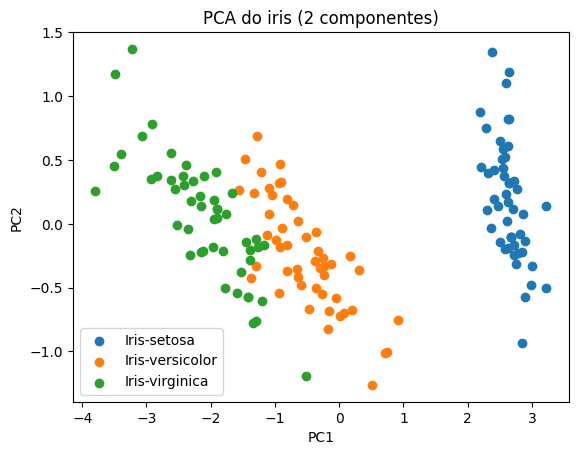

In [6]:
X_pca = iris_pca.X
y = iris_pca.y

classes = np.unique(y)

for c in classes:
    mask = (y == c)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=c)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA do iris (2 componentes)")
plt.legend()
plt.show()


# Exercício 6

**Exercício 6 – Stratified train-test split no iris**

In [8]:
train_ds, test_ds = stratified_train_test_split(
    iris_ds,
    test_size=0.3,
    random_state=42
)

print("Train shape:", train_ds.X.shape)
print("Test shape:", test_ds.X.shape)

print("Distribuição de classes - Total:", np.unique(iris_ds.y, return_counts=True))
print("Distribuição de classes - Train:", np.unique(train_ds.y, return_counts=True))
print("Distribuição de classes - Test:", np.unique(test_ds.y, return_counts=True))

Train shape: (105, 4)
Test shape: (45, 4)
Distribuição de classes - Total: (array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([50, 50, 50]))
Distribuição de classes - Train: (array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([35, 35, 35]))
Distribuição de classes - Test: (array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([15, 15, 15]))
